In [1]:
#!pip install camb

In [2]:
# Main dependencies
import scipy.fftpack
from scipy.interpolate import CubicSpline
import torch
import torchvision
import numpy as np
import matplotlib.pyplot as plt
import os
import camb
from camb import model, initialpower

print('Using CAMB %s installed at %s' % (camb.__version__, os.path.dirname(camb.__file__)))
# make sure the version and path is what you expect

Using CAMB 1.6.5 installed at /global/homes/a/ajtorres/.local/perlmutter/pytorch2.6.0/lib/python3.12/site-packages/camb


In [3]:
 h = 0.7    # reduced Hubble constant

In [4]:
def fftind(size):
    """ Returns a numpy array of shifted Fourier coordinates k_x k_y k_z.
        
        Input args:
            size (integer): The size of the coordinate array to create
        Returns:
            k_ind, numpy array of shape (3, size, size, size) with:
                k_ind[0,:,:,:]:  k_x components
                k_ind[1,:,:,:]:  k_y components
                k_ind[2,:,:,:]:  k_z components
            
        """
    #Below, I have added an extra ':size' to the make the output 3D
    k_ind = np.mgrid[:size, :size, :size] - int( (size + 1)/2 )
    k_ind = scipy.fftpack.fftshift(k_ind) / (1000*h) * 2*np.pi
    return( k_ind )

field_size = 64

'''
# k_idx lists all the coordinates in 3D k-space that I am considering
k_idx = fftind(field_size)
# possible_ks returns a 3D array listing the separation from the origin for each position in 3D k-space
possible_ks = np.sqrt(k_idx[0]**2 + k_idx[1]**2 + k_idx[2]**2 + 1e-10)
# unique_possible_ks is a 1D array containing only unique separations
unique_possible_ks = np.unique(np.ndarray.flatten(possible_ks))
'''
print()

In [5]:
# Set cosmological parameters
pars = camb.set_params(H0=67.5, ombh2=0.022, omch2=0.122, ns=0.965)

# Get matter power spectra at redshift 0
pars.set_matter_power(redshifts=[0.0], kmax=2.0)

# Non-Linear spectra (Halofit)
results = camb.get_results(pars)
pars.NonLinear = model.NonLinear_both
results.calc_power_spectra(pars)

# In order to get a reasonable number of galaxies (~10^6), I need my minimum k to be 0.001
# Maximum k should then be the number of voxels along one side of the field times the minimum
# k. My fields won't be able to resolve the effects of larger k.

mink = 2*np.pi*0.001 / (2*h) # Divided by 2 to account for maximum squashing
kh_nonlin, z_nonlin, pk_nonlin = results.get_matter_power_spectrum(minkh= mink, maxkh= field_size * mink * 4, npoints= 10000)
# Multiplied by 4 to account for previous division by 2 and the maximum stretching

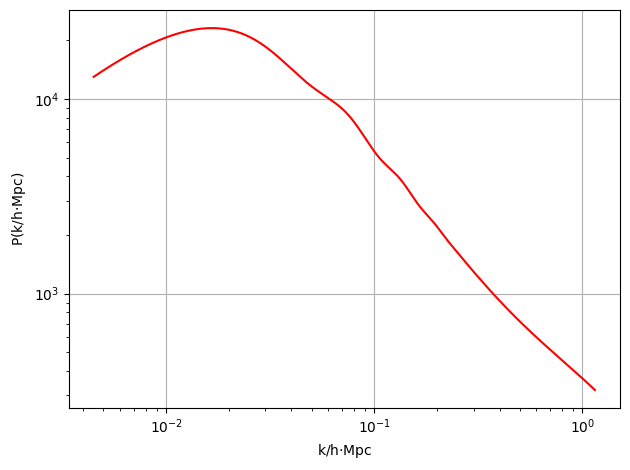

In [6]:
# Quick detour to plot power spectrum
plt.loglog(kh_nonlin, pk_nonlin[0, :], color='r')
plt.xlabel(r'k/h$\cdot$Mpc')
plt.ylabel(r'P(k/h$\cdot$Mpc)')
#plt.legend(['non-linear'], loc='lower left')
#plt.title('Matter Power Spectrum at z=%s' % 0.0);
plt.grid()
plt.tight_layout()
plt.savefig("matter_power_spectrum_no_title.png", dpi = 300)

When I multiply the k's along some axis by a stretch factor, let's say 2, I am considering up to 2 times larger k's and twice as large of a minimum k. This means that the total length of space considered along that axis is a factor of 2 smaller, but I have twice the resolution. Similarly, by dividing the total length of space considered along an axis by a stretch factor, let's say 2 again, I am considering k's that are not quite as large but a smaller minimum k. This translates to a greater length of space considered along that axis just at a less fine resolution.

In [7]:
# This is where I go on a little detour to check that an image actually looks different stretched versus unstretched
def unstretched_power(field_size):    
    # For each position in k-space, I want to calculate the separation from the origin
    k_idx = fftind(field_size)
    
    # We stretch physical space along one or more of the axes by a factor of the stretch
    # Stretch factor multiplied by k_idx[0] stretches the images horizontally
    # Stretch factor multiplied by k_idx[2] stretches the images vertically
    k_sep = np.sqrt(k_idx[0]**2 + k_idx[1]**2 + k_idx[2]**2)
    
    # Because we have not defined the power spectrum for every k we want to evaluate, we interpolate
    power_interpolator = CubicSpline(kh_nonlin, pk_nonlin[0], extrapolate = False)
    amplitude = power_interpolator(k_sep)
    amplitude[0][0][0] = 0
    
    return amplitude

In [8]:
def stretched_power(max_stretch, field_size):
    stretch = 2 #1.0 + np.random.randint(round(field_size * max_stretch) + 1)/(field_size)
    
    # For each position in k-space, I want to calculate the separation from the origin
    k_idx = fftind(field_size)
    
    # We stretch physical space along one or more of the axes by a factor of the stretch
    # Stretch factor multiplied by k_idx[0] stretches the images horizontally
    # Stretch factor multiplied by k_idx[2] stretches the images vertically
    k_sep = np.sqrt((k_idx[0] * stretch)**2 + (k_idx[1])**2 + (k_idx[2])**2)
    
    # Because we have not defined the power spectrum for every k we want to evaluate, we interpolate
    power_interpolator = CubicSpline(kh_nonlin, pk_nonlin[0], extrapolate = False)
    amplitude = power_interpolator(k_sep)
    amplitude[0][0][0] = 0
    
    return amplitude, stretch

In [9]:
def gaussian_random_field(size = field_size, flag_normalize = True):
    """
        Input args:
            size (integer):
                The size of the square output Gaussian Random Fields
            flag_normalize (boolean, default = True):
                Normalizes the Gaussian Field:
                    - to have an average of 0.0
                    - to have a standard deviation of 1.0

        Returns:
            gfield (numpy array of shape (size, size, size)):
                The random gaussian random field
                
        Example:
        import matplotlib.pyplot as plt
        example = gaussian_random_field()
        plt.imshow(example)
        """
 
        # Draws a complex gaussian random noise with normal (circular) distribution
    noise = np.random.normal(size = (size, size, size)) \
        + 1j * np.random.normal(size = (size, size, size))

    amplitude_us = np.sqrt(unstretched_power(field_size = size)) # Amplitudes of unstretched power spectrum
    power_s, stretch = stretched_power(max_stretch = 1.0, field_size = size) # Amplitudes of stretched power spectrum
    amplitude_s = np.sqrt(power_s)
    
        # To real space
    gfield_us = np.fft.ifftn(noise * amplitude_us).real
    gfield_s = np.fft.ifftn(noise * amplitude_s).real
    
        # Sets the standard deviation to one
    if flag_normalize:
        gfield_us = gfield_us - np.mean(gfield_us)
        gfield_us = gfield_us/np.std(gfield_us)
        gfield_s = gfield_s - np.mean(gfield_s)
        gfield_s = gfield_s/np.std(gfield_s)
        
    return gfield_s, gfield_us, stretch

In [10]:
import matplotlib as mpl

In [11]:
#print(mpl.colormaps)

1th set of unstretched and stretched fields


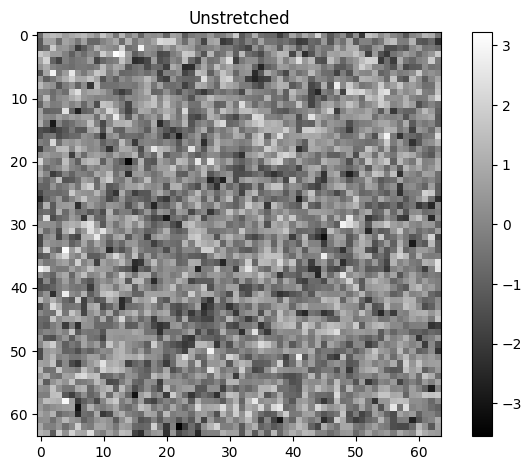

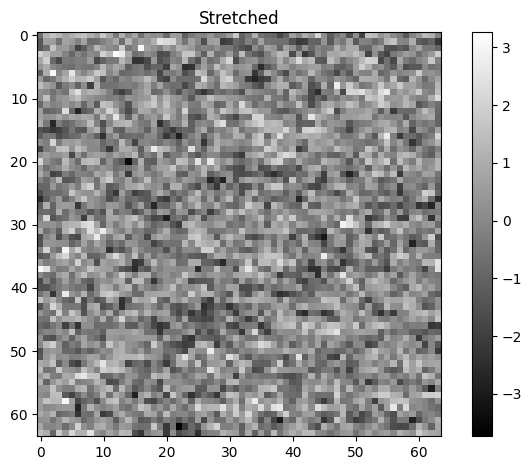

Horiztonal stretch factor is 2

2th set of unstretched and stretched fields


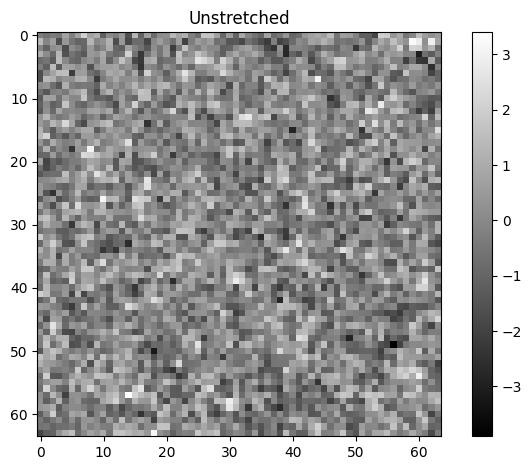

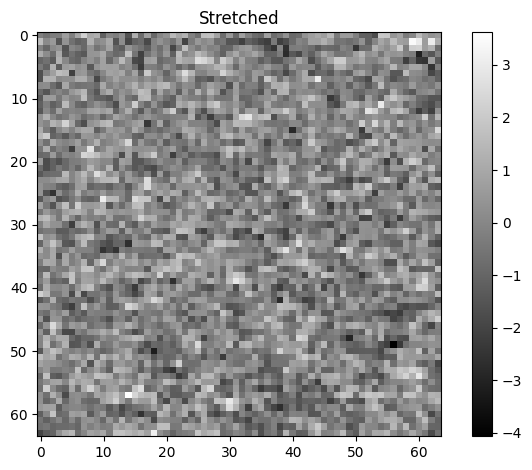

Horiztonal stretch factor is 2



In [15]:
for i in range(2):
    print(f"{i+1}th set of unstretched and stretched fields")
    field_s, field_us, stretch = gaussian_random_field()
    plt.title("Unstretched")
    plt.imshow(field_us[i], cmap = 'gray')
    plt.colorbar()
    plt.tight_layout()
    #plt.savefig(f"unstretched_gaussian_field_{i}.png")
    plt.show()
    plt.title("Stretched")
    plt.imshow(field_s[i],  cmap = 'gray')
    plt.colorbar()
    plt.tight_layout()
    #plt.savefig(f"stretched_gaussian_field_{i}.png")
    plt.show()
    print(f"Horiztonal stretch factor is {stretch}")
    print()

In [15]:
#Uncomment out if you want to look at the vertical stretching of the Gaussian random fields
'''
def stretched_power(max_stretch, field_size):
    stretch = 2 #1.0 + np.random.randint(round(field_size * max_stretch) + 1)/(field_size)
    
    # For each position in k-space, I want to calculate the separation from the origin
    k_idx = fftind(field_size)
    
    # We stretch physical space along one or more of the axes by a factor of the stretch
    # Stretch factor multiplied by k_idx[0] stretches the images horizontally
    # Stretch factor multiplied by k_idx[2] stretches the images vertically
    k_sep = np.sqrt((k_idx[0])**2 + (k_idx[1])**2 + (k_idx[2] * stretch)**2)
    
    # Because we have not defined the power spectrum for every k we want to evaluate, we interpolate
    power_interpolator = CubicSpline(kh_nonlin, pk_nonlin[0], extrapolate = False)
    amplitude = power_interpolator(k_sep)
    amplitude[0][0][0] = 0
    
    return amplitude, stretch

for i in range(2):
    field_s, field_us, stretch = gaussian_random_field()
    plt.imshow(field_us[i], cmap = 'gray')
    plt.show()
    plt.imshow(field_s[i], cmap = 'gray')
    plt.show()
    print(f"Vertical stretch factor is {stretch}")
'''
print()

In [16]:
def Gaussian_to_Galaxy_Field(N_gal):
    Gaussian_field, Gaussian_field_us, stretch = gaussian_random_field() #This gets us a 3D array with values representing a Gaussian random field with variance 1
    density_field_weights = np.exp(Gaussian_field - 1/2) #Takes Gaussian field and converts it to a realistic density field weighting
    sum_weights = np.sum(density_field_weights)
    galaxy_probs = density_field_weights / sum_weights
    
    # This uses the density field weighting and populates an array representing the actual distribution of galaxies in 3D space
    galaxy_probs_flat = galaxy_probs.flatten()
    N_gal_dist_flat = np.random.multinomial(N_gal, galaxy_probs_flat)
    N_gal_dist = N_gal_dist_flat.reshape((field_size, field_size, field_size))

    # again for unstretched field
    density_field_weights_us = np.exp(Gaussian_field_us - 1/2) #Takes Gaussian field and converts it to a realistic density field weighting
    sum_weights_us = np.sum(density_field_weights_us)
    galaxy_probs_us = density_field_weights_us / sum_weights_us
    
    # This uses the density field weighting and populates an array representing the actual distribution of galaxies in 3D space
    galaxy_probs_flat_us = galaxy_probs_us.flatten()
    N_gal_dist_flat_us = np.random.multinomial(N_gal, galaxy_probs_flat_us)
    N_gal_dist_us = N_gal_dist_flat_us.reshape((field_size, field_size, field_size))

    return N_gal_dist, N_gal_dist_us, stretch

In [17]:
# This is to figure out how many galaxies I would have in a box for each tracer
k_min = 1/1000 # Mpc^-1
box_volume = k_min ** -3 # Mpc^3
vol_tracer = 10**9 #Mpc^3
N_gal_tracer = 10**6

N_gal = round(N_gal_tracer / vol_tracer * box_volume) # multiply measured galaxy density by volume of my box
print(N_gal)

1000000


Unstretched:


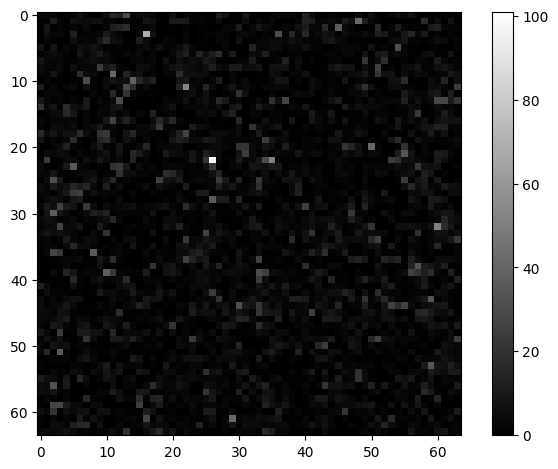

Stretched:


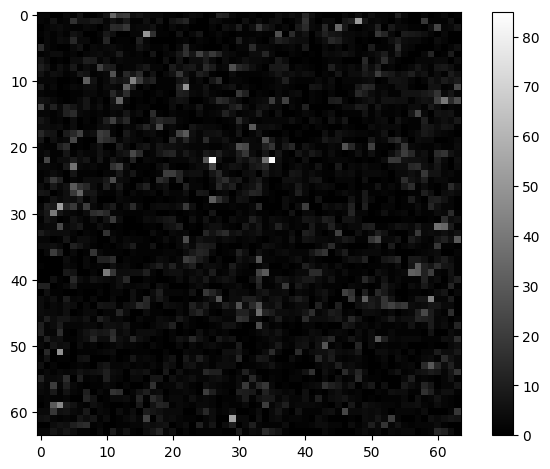

Horizontal stretch is 2
Unstretched:


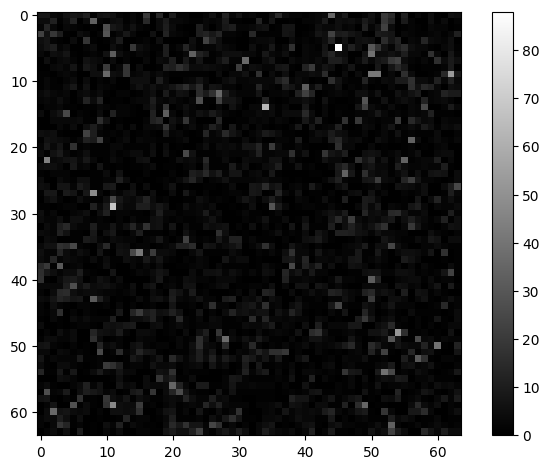

Stretched:


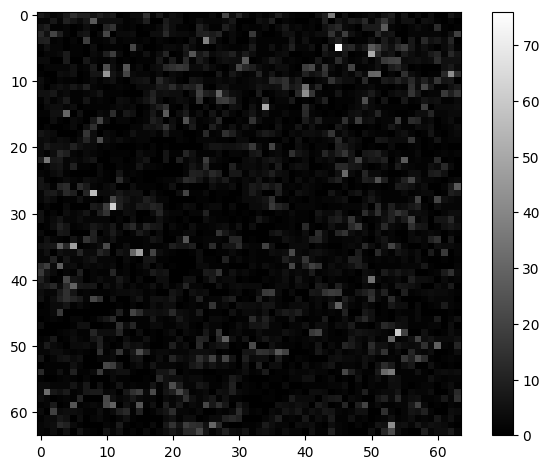

Horizontal stretch is 2
Number of galaxies in stretched field is 1000000, and the number in the unstretched field is 1000000


In [23]:
for i in range(2):
    #return 3D array with values representing a galaxy field
    print(f"{i+1}th set of unstretched and stretched fields")
    field_s, field_us, stretch = Gaussian_to_Galaxy_Field(N_gal)
    print("Unstretched:")
    plt.imshow(field_us[i], cmap = 'gray')
    plt.colorbar()
    plt.tight_layout()
    plt.savefig(f"unstretched_galaxy_field_{i}.png")
    plt.show()
    print("Stretched:")
    plt.imshow(field_s[i], cmap = 'gray')
    plt.colorbar()
    plt.tight_layout()
    plt.savefig(f"stretched_galaxy_field_{i}.png")
    plt.show()
    print(f"Horizontal stretch is {stretch}")

print(f"Number of galaxies in stretched field is {np.sum(field_s)}, and the number in the unstretched field is {np.sum(field_us)}")